# Gravnet 

*Turning point clouds into graphs*

---

**Point cloud** --*KNN*--> **Graph** --*Information Exchange*--> **Larger Graph** --*Coordinates as extra features*--> **Point Cloud**


**Configuration:**

    * n_dimensions=4
    * dshape=64
    * K=[128, 128, 128]



# Simple Gravnet

In [58]:
import tensorflow as tf

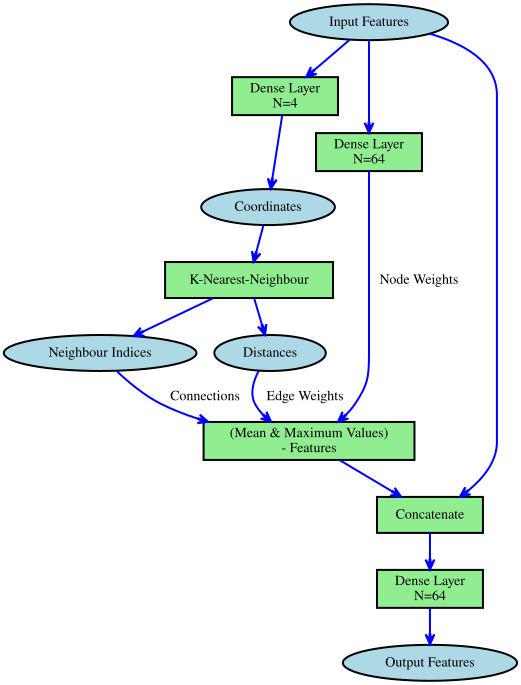

In [59]:
from graphviz import Digraph

# Initialize a directed graph with left-to-right orientation
dot = Digraph(comment='Styled Neural Network Model Block', engine='dot')
# dot.attr(rankdir='LR')  # Set graph orientation to Left-to-Right

# Define nodes with custom styles
dot.node('I', 'Input Features',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
dot.node('O', 'Output Features',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
dot.node('D1', r'Dense Layer\nN=4',
         shape='box', style='filled', fillcolor='lightgreen', fontcolor='black', penwidth='2')
dot.node('D2', r'Dense Layer\nN=64',
         shape='box', style='filled', fillcolor='lightgreen', fontcolor='black', penwidth='2')
dot.node('D3', r'Dense Layer\nN=64',
         shape='box', style='filled', fillcolor='lightgreen', fontcolor='black', penwidth='2')
dot.node('Coord', 'Coordinates',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
dot.node('KNN', r'K-Nearest-Neighbour',
         shape='box', style='filled', fillcolor='lightgreen', fontcolor='black', penwidth='2')
dot.node('Ns', 'Neighbour Indices',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
dot.node('Dists', 'Distances',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
# dot.node('Graph', 'Graph',
#          shape='diamond', style='filled', fillcolor='yellow', fontcolor='black', penwidth='2')
dot.node('MM', '(Mean & Maximum Values)\n- Features',
         shape='box', style='filled', fillcolor='lightgreen', fontcolor='black', penwidth='2')
dot.node('Concat', 'Concatenate',
         shape='box', style='filled', fillcolor='lightgreen', fontcolor='black', penwidth='2')

# Define sub-nodes for Information Exchange step with custom styles
# dot.node('C1', 'Transform Input Features\n(Dense Layer: N=64, ELU, HE_Normal)',
#          shape='box', style='filled', fillcolor='yellow', fontcolor='black', penwidth='2')
# dot.node('C2', 'Collect Neighbor Information\n(Mean & Max Aggregation)',
#          shape='box', style='filled', fillcolor='orange', fontcolor='black', penwidth='2')
# dot.node('C3', 'Transform Output Features\n(Dense Layer: N=64, ReLU)',
#          shape='box', style='filled', fillcolor='pink', fontcolor='black', penwidth='2')

# Define edges with custom styles
dot.edge('I', 'D1', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('D1', 'Coord', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('Coord', 'KNN', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('KNN', 'Dists', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('KNN', 'Ns', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('Ns', 'MM', color='blue', style='solid', label='Connections', penwidth='2', arrowhead='vee')
dot.edge('Dists', 'MM', color='blue', style='solid', label='Edge Weights', penwidth='2', arrowhead='vee')
dot.edge('I', 'D2', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('D2', 'MM', color='blue', style='solid', penwidth='2', label='Node Weights', arrowhead='vee')
dot.edge('I', 'Concat', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('MM', 'Concat', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('Concat', 'D3', color='blue', style='solid', penwidth='2', arrowhead='vee')
dot.edge('D3', 'O', color='blue', style='solid', penwidth='2', arrowhead='vee')
# dot.edge('C', 'C1', color='red', style='dashed', penwidth='2', arrowhead='vee')
# dot.edge('C1', 'C2', color='red', style='dashed', penwidth='2', arrowhead='vee')
# dot.edge('C2', 'C3', color='red', style='dashed', penwidth='2', arrowhead='vee')

# Render the graph to a file
# dot.render('styled_neural_network_model_block', format='png', view=True)
dot

## Steps

### Step 1 - Create input coordinates

Simple Dense without activation is used on features to create $4D$ coordinates
                
```python
coordinates = self.input_spatial_transform(x)

self.input_spatial_transform = tf.keras.layers.Dense(
    4,
    kernel_initializer=EyeInitializer(
        mean=0, stddev=1e-3)
    use_bias=False,
)
```

### Step 2 - Create Graph 
    
Coordinates are used to identify nearest neighbours and thus create a graph. 
This uses an implementation of a KNN with $K=128$

```python
neighbour_indices, distancesq, sidx, sdist = (
    self.compute_neighbours_and_distancesq(coordinates, row_splits)
)
```

### Step 3 - Information Exchange

Information exchange happens among neighbours on the graph. 
Distance is used as weights (decreasing with further distance).
1. Transform Input features with Dense layer
   * $N = 64$
   * "Elu" activation
   * "HE_Normal" initializer
2. Collect neighbour information
   * Return 'mean' and 'max' for every neighbourhood, increasing size by 2x
   * subtract original value for each point
   * concatenate original values, increasing size to 3x
3. Transform output features with Dense layer
    * $N=64$
    * "ReLu" actiavation

```python
outfeats = self.create_output_features(x, neighbour_indices, distancesq)

def create_output_features(self, x, neighbour_indices, distancesq):
    allfeat = []
    features = x

    features = self.input_feature_transform(features)
    prev_feat = features
    features = self.collect_neighbours(features, neighbour_indices, distancesq)
    features = tf.reshape(features, [-1, prev_feat.shape[1] * 2])
    features -= tf.tile(prev_feat, [1, 2])
    allfeat.append(features)

    features = tf.concat(allfeat + [x], axis=-1)
    return self.output_feature_transform(features)

self.input_feature_transform = tf.keras.layers.Dense(
    n_propagate,
    activation='elu',
    kernel_initializer="he_normal",
)

def collect_neighbours(self, features, neighbour_indices, distancesq):
    f, _ = AccumulateKnn(
        10.0 * distancesq, features, neighbour_indices, mean_and_max=True
    )
    return f

self.output_feature_transform = tf.keras.layers.Dense(
    self.n_filters, activation="relu"
)  # changed to relu
```

## Code

In [60]:
def call(self, inputs, training=None):
    x = inputs[0]
    row_splits = inputs[1]

    # Transform input coordinates
    coordinates = self.input_spatial_transform(x)
    neighbour_indices, distancesq, sidx, sdist = (
        self.compute_neighbours_and_distancesq(coordinates, row_splits)
    )
    neighbour_indices = tf.reshape(
        neighbour_indices, [-1, self.n_neighbours]
    )  # for proper output shape for keras
    distancesq = tf.reshape(distancesq, [-1, self.n_neighbours])

    outfeats = self.create_output_features(x, neighbour_indices, distancesq)

    return outfeats, coordinates, sidx, sdist


### Simplified Code

In [61]:

class RaggedGravNet(tf.keras.layers.Layer):
    def __init__(
        self,
        n_neighbours: int,
        n_dimensions: int,
        n_filters: int,
        n_propagate: int,
        return_self=True,
        sumwnorm=False,
        feature_activation="relu",
        use_approximate_knn=False,
        coord_initialiser_noise=1e-2,
        use_dynamic_knn=True,
        debug=False,
        n_knn_bins=None,
        _promptnames=None,  # compatibility, does nothing
        record_metrics=False,  # compatibility, does nothing
        **kwargs,
    ):
        """
        Call will return output features, coordinates, neighbor indices and squared distances from neighbors
        Inputs:
        - features
        - row splits

        :param n_neighbours: neighbors to do gravnet pass over
        :param n_dimensions: number of dimensions in spatial transformations
        :param n_filters:  number of dimensions in output feature transformation, could be list if multiple output
        features transformations (minimum 1)

        :param n_propagate: how much to propagate in feature tranformation, could be a list in case of multiple
        :param return_self: for the neighbour indices and distances, switch whether to return the 'self' index and distance (0)
        :param sumwnorm: normalise distance weights such that their sum is 1. (default False)
        :param feature_activation: activation to be applied to feature creation (F_LR) (default relu)
        :param use_approximate_knn: use approximate kNN method (SlicingKnn) instead of exact method (SelectKnn)
        :param use_dynamic_knn: uses dynamic adjustment of kNN binning derived from previous batches (only in effect together with use_approximate_knn)
        :param debug: switches on debug output, is not persistent when saving
        :param n_knn_bins: number of bins for included kNN (default: None=dynamic)
        :param kwargs:
        """
        super(RaggedGravNet, self).__init__(**kwargs)

        # n_neighbours += 1  # includes the 'self' vertex
        assert n_neighbours > 1
        assert not use_approximate_knn  # not needed anymore. Exact one is faster by now

        self.n_neighbours = n_neighbours
        self.n_dimensions = n_dimensions
        self.n_filters = n_filters
        self.return_self = return_self
        self.sumwnorm = sumwnorm
        self.feature_activation = feature_activation
        self.use_approximate_knn = use_approximate_knn
        self.use_dynamic_knn = use_dynamic_knn
        self.debug = debug
        self.n_knn_bins = n_knn_bins

        self.n_propagate = n_propagate
        self.n_prop_total = 2 * self.n_propagate

        with tf.name_scope(self.name + "/1/"):
            self.input_feature_transform = tf.keras.layers.Dense(
                n_propagate,
                activation=feature_activation,
                kernel_initializer="he_normal",
            )

        with tf.name_scope(self.name + "/2/"):
            s_kernel_initializer = "glorot_uniform"
            if coord_initialiser_noise is not None:
                s_kernel_initializer = EyeInitializer(
                    mean=0, stddev=coord_initialiser_noise
                )
            self.input_spatial_transform = tf.keras.layers.Dense(
                n_dimensions,
                # very slow turn on
                kernel_initializer=s_kernel_initializer,
                use_bias=False,
            )

        with tf.name_scope(self.name + "/3/"):
            self.output_feature_transform = tf.keras.layers.Dense(
                self.n_filters, activation="relu"
            )  # changed to relu

    def build(self, input_shapes):
        input_shape = input_shapes[0]

        with tf.name_scope(self.name + "/1/"):
            self.input_feature_transform.build(input_shape)

        with tf.name_scope(self.name + "/2/"):
            if len(input_shapes) == 3:  # extra coords
                c_shape = [s for s in input_shape]
                c_shape[-1] += input_shapes[2][-1]
                self.input_spatial_transform.build(c_shape)
            else:
                self.input_spatial_transform.build(input_shape)

        with tf.name_scope(self.name + "/3/"):
            self.output_feature_transform.build(
                (input_shape[0], self.n_prop_total + input_shape[1])
            )

        with tf.name_scope(self.name + "/4/"):
            self.dynamic_radius = self.add_weight(
                name="dynamic_radius",
                initializer=tf.constant_initializer(1.0),
                trainable=False,
            )

        super(RaggedGravNet, self).build(input_shape)

    # @tf.function
    def create_output_features(self, x, neighbour_indices, distancesq):
        allfeat = []
        features = x

        features = self.input_feature_transform(features)
        prev_feat = features
        features = self.collect_neighbours(features, neighbour_indices, distancesq)
        features = tf.reshape(features, [-1, prev_feat.shape[1] * 2])
        features -= tf.tile(prev_feat, [1, 2])
        allfeat.append(features)

        features = tf.concat(allfeat + [x], axis=-1)
        return self.output_feature_transform(features)

    # @tf.function(reduce_retracing=True) #don't know why this is being retraced so often..
    def priv_call(self, x, row_splits, x_coord):

        coordinates = self.input_spatial_transform(x_coord)
        neighbour_indices, distancesq, sidx, sdist = (
            self.compute_neighbours_and_distancesq(coordinates, row_splits)
        )
        neighbour_indices = tf.reshape(
            neighbour_indices, [-1, self.n_neighbours]
        )  # for proper output shape for keras
        distancesq = tf.reshape(distancesq, [-1, self.n_neighbours])

        outfeats = self.create_output_features(x, neighbour_indices, distancesq)
        if self.return_self:
            neighbour_indices, distancesq = sidx, sdist
        return outfeats, coordinates, neighbour_indices, distancesq

    def call(self, inputs, training=None):
        x = inputs[0]
        row_splits = inputs[1]
        x_coord = x
        if len(inputs) == 3:
            x_coord = tf.concat([inputs[2], x], axis=-1)

        return self.priv_call(x, row_splits, x_coord)

    def compute_output_shape(self, input_shapes):
        if self.return_self:
            return (
                (input_shapes[0][0], 2 * self.n_filters),
                (input_shapes[0][0], self.n_dimensions),
                (input_shapes[0][0], self.n_neighbours + 1),
                (input_shapes[0][0], self.n_neighbours + 1),
            )
        else:
            return (
                (input_shapes[0][0], 2 * self.n_filters),
                (input_shapes[0][0], self.n_dimensions),
                (input_shapes[0][0], self.n_neighbours),
                (input_shapes[0][0], self.n_neighbours),
            )

    # @tf.function
    def compute_neighbours_and_distancesq(self, coordinates, row_splits):

        idx, dist = BinnedSelectKnn(
            self.n_neighbours + 1,
            coordinates,
            row_splits,
            max_radius=-1.0,
            tf_compatible=False,
            n_bins=self.n_knn_bins,
            name=self.name,
        )
        idx = tf.reshape(idx, [-1, self.n_neighbours + 1])
        dist = tf.reshape(dist, [-1, self.n_neighbours + 1])

        dist = tf.where(idx < 0, 0.0, dist)

        return idx[:, 1:], dist[:, 1:], idx, dist

    def collect_neighbours(self, features, neighbour_indices, distancesq):
        f = None
        if self.sumwnorm:
            f, _ = AccumulateKnnSumw(
                10.0 * distancesq, features, neighbour_indices, mean_and_max=True
            )
        else:
            f, _ = AccumulateKnn(
                10.0 * distancesq, features, neighbour_indices, mean_and_max=True
            )
        return f

    def get_config(self):
        config = {
            "n_neighbours": self.n_neighbours,
            "n_dimensions": self.n_dimensions,
            "n_filters": self.n_filters,
            "n_propagate": self.n_propagate,
            "return_self": self.return_self,
            "sumwnorm": self.sumwnorm,
            "feature_activation": self.feature_activation,
            "use_approximate_knn": self.use_approximate_knn,
            "n_knn_bins": self.n_knn_bins,
        }
        base_config = super(RaggedGravNet, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

    @staticmethod
    def set_all_gn_space_trainable(model, trainable=True):
        for l in model.layers:
            if isinstance(l, RaggedGravNet):
                l.input_spatial_transform.trainable = trainable


### Raw Code


In [62]:
class RaggedGravNet(tf.keras.layers.Layer):
    def __init__(
        self,
        n_neighbours: int,
        n_dimensions: int,
        n_filters: int,
        n_propagate: int,
        return_self=True,
        sumwnorm=False,
        feature_activation="relu",
        use_approximate_knn=False,
        coord_initialiser_noise=1e-2,
        use_dynamic_knn=True,
        debug=False,
        n_knn_bins=None,
        _promptnames=None,  # compatibility, does nothing
        record_metrics=False,  # compatibility, does nothing
        **kwargs,
    ):
        """
        Call will return output features, coordinates, neighbor indices and squared distances from neighbors
        Inputs:
        - features
        - row splits

        :param n_neighbours: neighbors to do gravnet pass over
        :param n_dimensions: number of dimensions in spatial transformations
        :param n_filters:  number of dimensions in output feature transformation, could be list if multiple output
        features transformations (minimum 1)

        :param n_propagate: how much to propagate in feature tranformation, could be a list in case of multiple
        :param return_self: for the neighbour indices and distances, switch whether to return the 'self' index and distance (0)
        :param sumwnorm: normalise distance weights such that their sum is 1. (default False)
        :param feature_activation: activation to be applied to feature creation (F_LR) (default relu)
        :param use_approximate_knn: use approximate kNN method (SlicingKnn) instead of exact method (SelectKnn)
        :param use_dynamic_knn: uses dynamic adjustment of kNN binning derived from previous batches (only in effect together with use_approximate_knn)
        :param debug: switches on debug output, is not persistent when saving
        :param n_knn_bins: number of bins for included kNN (default: None=dynamic)
        :param kwargs:
        """
        super(RaggedGravNet, self).__init__(**kwargs)

        # n_neighbours += 1  # includes the 'self' vertex
        assert n_neighbours > 1
        assert not use_approximate_knn  # not needed anymore. Exact one is faster by now

        self.n_neighbours = n_neighbours
        self.n_dimensions = n_dimensions
        self.n_filters = n_filters
        self.return_self = return_self
        self.sumwnorm = sumwnorm
        self.feature_activation = feature_activation
        self.use_approximate_knn = use_approximate_knn
        self.use_dynamic_knn = use_dynamic_knn
        self.debug = debug
        self.n_knn_bins = n_knn_bins

        self.n_propagate = n_propagate
        self.n_prop_total = 2 * self.n_propagate

        with tf.name_scope(self.name + "/1/"):
            self.input_feature_transform = tf.keras.layers.Dense(
                n_propagate,
                activation=feature_activation,
                kernel_initializer="he_normal",
            )

        with tf.name_scope(self.name + "/2/"):
            s_kernel_initializer = "glorot_uniform"
            if coord_initialiser_noise is not None:
                s_kernel_initializer = EyeInitializer(
                    mean=0, stddev=coord_initialiser_noise
                )
            self.input_spatial_transform = tf.keras.layers.Dense(
                n_dimensions,
                # very slow turn on
                kernel_initializer=s_kernel_initializer,
                use_bias=False,
            )

        with tf.name_scope(self.name + "/3/"):
            self.output_feature_transform = tf.keras.layers.Dense(
                self.n_filters, activation="relu"
            )  # changed to relu

    def build(self, input_shapes):
        input_shape = input_shapes[0]

        with tf.name_scope(self.name + "/1/"):
            self.input_feature_transform.build(input_shape)

        with tf.name_scope(self.name + "/2/"):
            if len(input_shapes) == 3:  # extra coords
                c_shape = [s for s in input_shape]
                c_shape[-1] += input_shapes[2][-1]
                self.input_spatial_transform.build(c_shape)
            else:
                self.input_spatial_transform.build(input_shape)

        with tf.name_scope(self.name + "/3/"):
            self.output_feature_transform.build(
                (input_shape[0], self.n_prop_total + input_shape[1])
            )

        with tf.name_scope(self.name + "/4/"):
            self.dynamic_radius = self.add_weight(
                name="dynamic_radius",
                initializer=tf.constant_initializer(1.0),
                trainable=False,
            )

        super(RaggedGravNet, self).build(input_shape)

    # @tf.function
    def create_output_features(self, x, neighbour_indices, distancesq):
        allfeat = []
        features = x

        features = self.input_feature_transform(features)
        prev_feat = features
        features = self.collect_neighbours(features, neighbour_indices, distancesq)
        features = tf.reshape(features, [-1, prev_feat.shape[1] * 2])
        features -= tf.tile(prev_feat, [1, 2])
        allfeat.append(features)

        features = tf.concat(allfeat + [x], axis=-1)
        return self.output_feature_transform(features)

    # @tf.function(reduce_retracing=True) #don't know why this is being retraced so often..
    def priv_call(self, x, row_splits, x_coord):

        coordinates = self.input_spatial_transform(x_coord)
        neighbour_indices, distancesq, sidx, sdist = (
            self.compute_neighbours_and_distancesq(coordinates, row_splits)
        )
        neighbour_indices = tf.reshape(
            neighbour_indices, [-1, self.n_neighbours]
        )  # for proper output shape for keras
        distancesq = tf.reshape(distancesq, [-1, self.n_neighbours])

        outfeats = self.create_output_features(x, neighbour_indices, distancesq)
        if self.return_self:
            neighbour_indices, distancesq = sidx, sdist
        return outfeats, coordinates, neighbour_indices, distancesq

    def call(self, inputs, training=None):
        x = inputs[0]
        row_splits = inputs[1]
        x_coord = x
        if len(inputs) == 3:
            x_coord = tf.concat([inputs[2], x], axis=-1)

        return self.priv_call(x, row_splits, x_coord)

    def compute_output_shape(self, input_shapes):
        if self.return_self:
            return (
                (input_shapes[0][0], 2 * self.n_filters),
                (input_shapes[0][0], self.n_dimensions),
                (input_shapes[0][0], self.n_neighbours + 1),
                (input_shapes[0][0], self.n_neighbours + 1),
            )
        else:
            return (
                (input_shapes[0][0], 2 * self.n_filters),
                (input_shapes[0][0], self.n_dimensions),
                (input_shapes[0][0], self.n_neighbours),
                (input_shapes[0][0], self.n_neighbours),
            )

    # @tf.function
    def compute_neighbours_and_distancesq(self, coordinates, row_splits):

        idx, dist = BinnedSelectKnn(
            self.n_neighbours + 1,
            coordinates,
            row_splits,
            max_radius=-1.0,
            tf_compatible=False,
            n_bins=self.n_knn_bins,
            name=self.name,
        )
        idx = tf.reshape(idx, [-1, self.n_neighbours + 1])
        dist = tf.reshape(dist, [-1, self.n_neighbours + 1])

        dist = tf.where(idx < 0, 0.0, dist)

        return idx[:, 1:], dist[:, 1:], idx, dist

    def collect_neighbours(self, features, neighbour_indices, distancesq):
        f = None
        if self.sumwnorm:
            f, _ = AccumulateKnnSumw(
                10.0 * distancesq, features, neighbour_indices, mean_and_max=True
            )
        else:
            f, _ = AccumulateKnn(
                10.0 * distancesq, features, neighbour_indices, mean_and_max=True
            )
        return f

    def get_config(self):
        config = {
            "n_neighbours": self.n_neighbours,
            "n_dimensions": self.n_dimensions,
            "n_filters": self.n_filters,
            "n_propagate": self.n_propagate,
            "return_self": self.return_self,
            "sumwnorm": self.sumwnorm,
            "feature_activation": self.feature_activation,
            "use_approximate_knn": self.use_approximate_knn,
            "n_knn_bins": self.n_knn_bins,
        }
        base_config = super(RaggedGravNet, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

    @staticmethod
    def set_all_gn_space_trainable(model, trainable=True):
        for l in model.layers:
            if isinstance(l, RaggedGravNet):
                l.input_spatial_transform.trainable = trainable



# Gravnet + TEQMP


## Code

```python
def GravNet_plus_TEQMP(
    name,
    x,
    cprime,
    hit_energy,
    t_idx,
    rs,
    d_shape,
    n_neighbours,
    debug_outdir,
    plot_debug_every,
    debug_publish=None,
    space_reg_strength=-1.0,
    n_gn_coords=4,
    teq_nodes=[64, 32, 16, 8],
    return_coords=False,
    trainable=True,
    add_scaling=True,
):

    xgn, gncoords, gnnidx, gndist = RaggedGravNet(
        name="GravNet_" + name,  # 76929, 42625, 42625
        n_neighbours=n_neighbours,
        n_dimensions=n_gn_coords,
        n_filters=d_shape,
        n_propagate=d_shape,
        coord_initialiser_noise=1e-3,
        feature_activation="elu",
        trainable=trainable,
    )([x, rs])

    if space_reg_strength > 0:
        gndist = LLRegulariseGravNetSpace(
            name=f"gravnet_coords_reg_{name}",
            record_metrics=True,
            scale=space_reg_strength,
        )([gndist, cprime, gnnidx])

    gncoords = PlotCoordinates(
        plot_every=plot_debug_every,
        outdir=debug_outdir,
        name=f"gncoords_{name}",
        publish=debug_publish,
    )([gncoords, hit_energy, t_idx, rs])

    x = DummyLayer()(
        [x, gncoords]
    )  # just so the branch is not optimised away, anyway used further down
    x = Concatenate()([xgn, x])

    dscale = Dense(1, name=name + "_dscale", trainable=trainable)(
        x
    )  # FIXME sigmoid needs to go
    # dscale = ScalarMultiply(2.)(dscale)
    # dscale = Multiply()([dscale, dscale]) # as distances are also quadratic
    gndist = LocalDistanceScaling()([gndist, dscale])

    x = TranslationInvariantMP(
        teq_nodes,
        layer_norm=True,
        activation=None,  # layer norm takes care
        sum_weight=False,
        name=name + "_teqmp",
        trainable=trainable,
    )([x, gnnidx, gndist])

    if return_coords:
        return Concatenate()([xgn, x]), gncoords
    return Concatenate()([xgn, x])

```

# TranslationInvariantMP

Building Block 

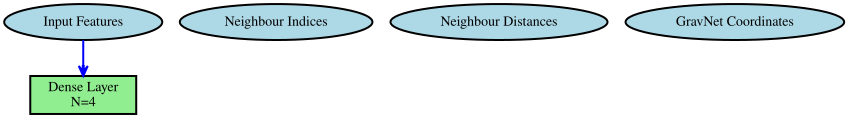

In [67]:
dot = Digraph(comment='Styled Neural Network Model Block', engine='dot')
# dot.attr(rankdir='LR')  # Set graph orientation to Left-to-Right

# Define nodes with custom styles
dot.node('I', 'Input Features',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
dot.node('Nid', 'Neighbour Indices',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
dot.node('Ndist', 'Neighbour Distances',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
dot.node('Gcoords', r'GravNet Coordinates',
         shape='ellipse', style='filled', fillcolor='lightblue', fontcolor='black', penwidth='2')
dot.node('D1', r'Dense Layer\nN=4',
         shape='box', style='filled', fillcolor='lightgreen', fontcolor='black', penwidth='2')
dot.edge('I', 'D1', color='blue', style='solid', penwidth='2', arrowhead='vee')
# dot.node('Gcoords', r'GravNet Coordinates',
#          shape='box', style='filled', fillcolor='lightgreen', fontcolor='black', penwidth='2')
dot

In [ ]:
def call(self, inputs):
    x, neighbour_indices, distancesq = inputs
    allfeat = []
    features = x
    K = tf.cast(tf.shape(neighbour_indices)[1], "float32")

    i = 0
    features = layernorm(features)
    prev_feat = features
    # add a 1 to the features for translation invariance later
    ones = tf.ones_like(features[:, 0:1])
    features = tf.concat([ones, features], axis=-1)
    # Standard Message Passing
    features = (
        AccumulateKnn(
            10.0 * distancesq, features, neighbour_indices, mean_and_max=False
        )[0]
        * K
    )

    # this is only necessary for the first exchange, afterwards the features are already translation independent
    minus_xi = features[:, 0:1]
    features = features[:, 1:]
    features -= prev_feat * minus_xi
    features = features / K
    t = self.feature_tranformation_dense[i]
    features = t(features)  # divide by K here again
    allfeat.append(features)

    for i in range(1, len(self.n_feature_transformation)):
        features = layernorm(features)
        prev_feat = features
        # add a 1 to the features for translation invariance later
        # Standard Message Passing
        features = (
            AccumulateKnn(
                10.0 * distancesq, features, neighbour_indices, mean_and_max=False
            )[0]
            * K
        )

        # this is only necessary for the first exchange, afterwards the features are already translation independent
        features = features / K
        t = self.feature_tranformation_dense[i]
        features = t(features)  # divide by K here again
        allfeat.append(features)

    features = tf.concat(allfeat, axis=-1)
    features = tf.reshape(features, [-1, sum(self.n_feature_transformation)])

    return features


## Code


```python
class TranslationInvariantMP(tf.keras.layers.Layer):
    def __init__(
        self,
        n_feature_transformation,
        activation="elu",
        mean=True,
        layer_norm=False,
        sum_weight=False,
        **kwargs,
    ):
        super(TranslationInvariantMP, self).__init__(**kwargs)

        self.n_feature_transformation = n_feature_transformation
        self.activation = activation
        initializer = "he_normal"
        self.mean = mean
        self.layer_norm = layer_norm
        self.sum_weight = sum_weight
        self.feature_tranformation_dense = []
        for i in range(len(self.n_feature_transformation)):
            with tf.name_scope(self.name + "/" + str(i)):
                self.feature_tranformation_dense.append(
                    tf.keras.layers.Dense(
                        n_feature_transformation[i],
                        activation=activation,
                        kernel_initializer=initializer,
                        trainable=self.trainable,
                        use_bias=i > 0,
                    )
                )

    def build(self, input_shapes):
        input_shape = input_shapes[0]

        with tf.name_scope(self.name + "/" + str(0)):
            self.feature_tranformation_dense[0].build(input_shape)

        for i in range(1, len(self.feature_tranformation_dense)):
            with tf.name_scope(self.name + "/" + str(i)):
                self.feature_tranformation_dense[i].build(
                    (input_shape[0], self.n_feature_transformation[i - 1])
                )

        super(TranslationInvariantMP, self).build(input_shapes)

    def compute_output_shape(self, inputs_shapes):
        fshape = inputs_shapes[0][-1]
        return (None, sum(self.n_feature_transformation))

    def get_config(self):
        config = {
            "n_feature_transformation": self.n_feature_transformation,
            "activation": self.activation,
            "mean": self.mean,
            "layer_norm": self.layer_norm,
            "sum_weight": self.sum_weight,
        }
        base_config = super(TranslationInvariantMP, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

    def _trf_loop(self, features, neighbour_indices, distancesq, K, first):

        if self.layer_norm:
            features = layernorm(features)
        prev_feat = features
        if self.mean:
            # add a 1 to the features for translation invariance later
            if first:
                ones = tf.ones_like(features[:, 0:1])
                features = tf.concat([ones, features], axis=-1)
            # Standard Message Passing
            features = (
                AccumulateKnn(
                    10.0 * distancesq, features, neighbour_indices, mean_and_max=False
                )[0]
                * K
            )

            # this is only necessary for the first exchange, afterwards the features are already translation independent
            if first:
                minus_xi = features[:, 0:1]
                features = features[:, 1:]
                features -= prev_feat * minus_xi
            if self.sum_weight:
                wsum = tf.math.divide_no_nan(
                    K,
                    tf.reduce_sum(tf.exp(-10.0 * distancesq), axis=1, keepdims=True)
                    + 1e-2,
                )  # large eps
                features *= wsum
        else:  # max
            nfeat = SelectWithDefault(neighbour_indices, features, -2.0)
            features = (
                tf.reduce_max(
                    tf.exp(-10.0 * distancesq) * nfeat - features[:, tf.newaxis, :],
                    axis=1,
                )
                * K
            )

        return features / K

    def create_output_features(self, x, neighbour_indices, distancesq):
        allfeat = []
        features = x
        K = tf.cast(tf.shape(neighbour_indices)[1], "float32")

        for i in range(len(self.n_feature_transformation)):
            features = self._trf_loop(
                features, neighbour_indices, distancesq, K, i == 0
            )
            t = self.feature_tranformation_dense[i]
            features = t(features)  # divide by K here again
            allfeat.append(features)

        features = tf.concat(allfeat, axis=-1)
        features = tf.reshape(features, [-1, sum(self.n_feature_transformation)])
        return features

    # @tf.function
    def call(self, inputs):
        if len(inputs) == 3:
            x, neighbor_indices, distancesq = inputs
        elif len(inputs) == 2:
            x, neighbor_indices = inputs
            distancesq = tf.zeros_like(neighbor_indices, dtype="float32")
        else:
            raise ValueError(self.name + " was passed wrong inputs")

        return self.create_output_features(x, neighbor_indices, distancesq)
```

# STUFF